In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [19]:
from dataset.dataloader import get_dataset, get_dataloaders
from dataset.transforms import get_train_transform, get_age_transform, get_val_transform

In [20]:
from model.clip   import processor as clip_processor
from model.dinov2 import processor as dinov2_processor
from model.siglip import processor as siglip_processor

In [ ]:
print(clip_processor.image_processor)

In [ ]:
print(siglip_processor)

In [ ]:
print(dinov2_processor)

In [24]:
train_set, val_set = get_dataset(
    get_train_transform(clip_processor.image_processor), 
    get_age_transform(clip_processor.image_processor), 
    get_val_transform(clip_processor.image_processor)
)
train_dataloader, val_dataloader = get_dataloaders(train_set, val_set)

In [53]:
print(len(train_set))              # size of the split
print(len(train_set.dataset))      # size of the full underlying dataset

86744
86744


AttributeError: 'FairFaceDataset' object has no attribute 'indices'

In [25]:
import torch

In [26]:
print(len(train_dataloader))
X, Y = next(iter(train_dataloader))
# images and lables blongs to 32 samples (1 batch) 

2711


In [27]:

for k, v in Y.items():
    print(k, v.shape, v.dtype)

gender torch.Size([32]) torch.int64
age torch.Size([32]) torch.int64
race torch.Size([32]) torch.int64


In [30]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [31]:
df = pd.DataFrame({
    "age": train_set.dataset["age"],
    "gender": train_set.dataset["gender"],
    "race": train_set.dataset["race"],
})
print(train_set.dataset)

Dataset({
    features: ['image', 'age', 'gender', 'race', 'service_test'],
    num_rows: 86744
})


In [32]:
age_names = ["0: 0-2","1: 3-9","2: 10-19","3: 20-29",
             "4: 30-39","5: 40-49","6: 50-59",
             "7: 60-69","8: more than 70"]
gender_names = ["0: Male","1: Female"]
race_names = ["0: East Asian","1: Indian","2: Black",
              "3: White","4: Middle Eastern",
              "5: Latino_Hispanic","6: Southeast Asian"]

In [52]:
print(np.unique(df['gender']))
print(np.unique(df['race']))
print(np.unique(df['age']))
print(df['age'].values)

[0 1]
[0 1 2 3 4 5 6]
[0 1 2 3 4 5 6 7 8]
[6 4 1 ... 8 2 5]


## Gender

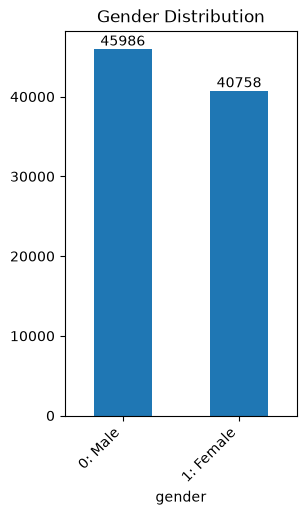

In [33]:

counts = df['gender'].value_counts().sort_index()
# print(counts)

ax = counts.plot(kind='bar', figsize=(3,5), title='Gender Distribution')
ax.set_xticklabels(gender_names, rotation=45, ha='right')
ax.bar_label(ax.containers[0])
plt.show()

## Age

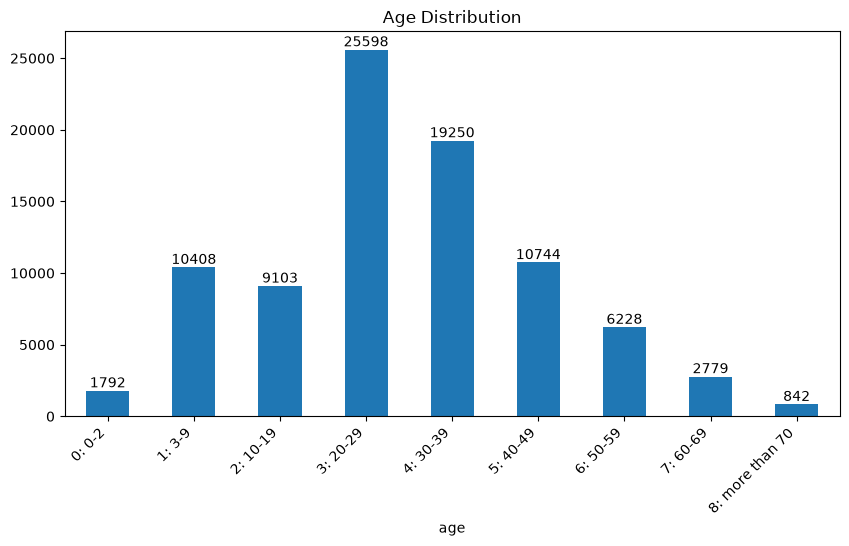

In [34]:

counts = df['age'].value_counts().sort_index()


ax = counts.plot(kind='bar', figsize=(10,5), title='Age Distribution')
ax.set_xticklabels(age_names, rotation=45, ha='right')
ax.bar_label(ax.containers[0])
plt.show()

## Race

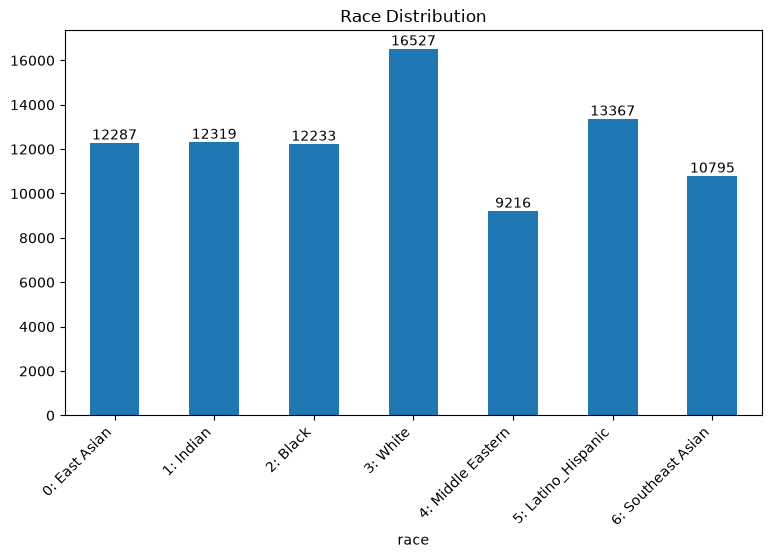

In [35]:
counts = df['race'].value_counts().sort_index()

ax = counts.plot(kind='bar', figsize=(9,5), title='Race Distribution')
ax.set_xticklabels(race_names, rotation=45, ha='right')
ax.bar_label(ax.containers[0])
plt.show()

## Describe

In [36]:
print(df['gender'].value_counts())
print(df['age'].value_counts())
print(df['race'].value_counts())

print(df.describe(include="all"))
print("\nImbalance ratios:")
for col in ["age", "gender", "race"]:
    counts = df[col].value_counts()
    print(f"{col}: max/min ratio = {counts.max()/counts.min():.2f}")



gender
0    45986
1    40758
Name: count, dtype: int64
age
3    25598
4    19250
5    10744
1    10408
2     9103
6     6228
7     2779
0     1792
8      842
Name: count, dtype: int64
race
3    16527
5    13367
1    12319
0    12287
2    12233
6    10795
4     9216
Name: count, dtype: int64
                age        gender          race
count  86744.000000  86744.000000  86744.000000
mean       3.454821      0.469865      2.937782
std        1.637914      0.499094      1.955181
min        0.000000      0.000000      0.000000
25%        3.000000      0.000000      1.000000
50%        3.000000      0.000000      3.000000
75%        4.000000      1.000000      5.000000
max        8.000000      1.000000      6.000000

Imbalance ratios:
age: max/min ratio = 30.40
gender: max/min ratio = 1.13
race: max/min ratio = 1.79


## Plot Random Samples

In [42]:
import math

def show_samples(dataframe, n=8, cols=4):
    samples = dataframe.sample(n)
    
    rows = math.ceil(n / cols)

    plt.figure(figsize=(cols * 3, rows * 3))
    
    for i, (sample_idx, s) in enumerate(samples.iterrows()):
        img = train_set[sample_idx][0]
        plt.subplot(rows, cols, i+1)  # rows, cols
        plt.imshow(img.permute(1, 2, 0))
        print(img.permute(1, 2, 0).min())
        print(img.permute(1, 2, 0).max())
        plt.axis("off")
        plt.title(f"{sample_idx},{race_names[s['race']]}")
    
    plt.show()

In [38]:
age_class_0 = df[df['age'] == 0]
age_class_7 = df[df['age'] == 7]
age_class_8 = df[df['age'] == 8]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7192703..2.0890172].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7776641..0.7665507].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6320349..1.3026041].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7922626..2.145897].


tensor(-1.7193)
tensor(2.0890)
tensor(-1.7777)
tensor(0.7666)
tensor(-1.6320)
tensor(1.3026)
tensor(-1.7923)
tensor(2.1459)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7220815..1.2588089].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5119728..1.7335154].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7922626..1.6237694].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7484672..1.7551552].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7922626..1.4923836].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5870117..1.7335154].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.544089

tensor(-1.7221)
tensor(1.2588)
tensor(-1.5120)
tensor(1.7335)
tensor(-1.7923)
tensor(1.6238)
tensor(-1.7485)
tensor(1.7552)
tensor(-1.7923)
tensor(1.4924)
tensor(-1.5870)
tensor(1.7335)
tensor(-1.5441)
tensor(1.3756)
tensor(-1.7923)
tensor(1.4486)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7922626..1.6908551].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7630657..2.145897].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7922626..2.145897].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7630657..0.68947].


tensor(-1.7923)
tensor(1.6909)
tensor(-1.7631)
tensor(2.1459)
tensor(-1.7923)
tensor(2.1459)
tensor(-1.7631)
tensor(0.6895)


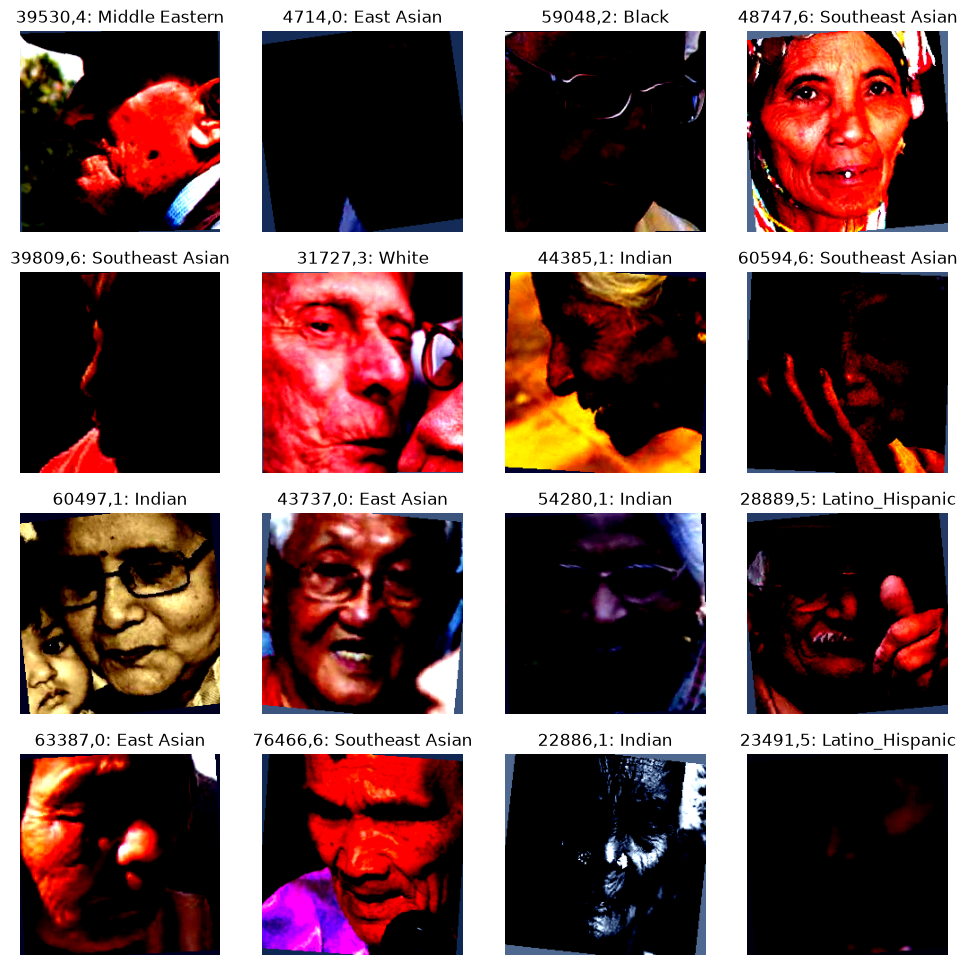

In [43]:
show_samples(age_class_8, n=16)